In [4]:
import tensorflow as tf

In [5]:
fashion_mnist = tf.keras.datasets.fashion_mnist

In [6]:
(train_X, train_y), (test_X, test_y) = fashion_mnist.load_data()

In [7]:
train_X = train_X/255.0
test_X  = test_X/255.0

In [8]:
train_X = train_X.reshape(-1, 28, 28, 1)
test_X = test_X.reshape(-1, 28, 28, 1)

In [9]:
print(train_X.shape)

(60000, 28, 28, 1)


In [10]:
model = tf.keras.Sequential(
	[
		# Input Layer
		tf.keras.layers.Input(shape=(28, 28, 1)),

		# Hidden Layer (특징 추출)
		tf.keras.layers.Conv2D(kernel_size=(3,3), filters=16), #(26, 26, 16)
		tf.keras.layers.Conv2D(kernel_size=(3,3), filters=32), #(24, 24, 32)
		tf.keras.layers.Conv2D(kernel_size=(3,3), filters=64), #(22, 22, 64)
		
		# Hidden layer (합치기)
		tf.keras.layers.Flatten(), #(22*22*64) → (30976)
		tf.keras.layers.Dense(units=128, activation="relu"),

		# Output Layer
		tf.keras.layers.Dense(units=10, activation="softmax")
	]
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,642 (15.22 MB)

 Trainable params: 3,989,642 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
	loss = "sparse_categorical_crossentropy", #모델이 얼마나 맞췄는지? 틀렸는지? 원핫인코딩
	optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001), #이 가중치는 많이 조정, 저 가중치는 조금 조정
	metrics = ["accuracy"] #학습이 잘 되고 있는지 사람이 보기 위한 성적표
)

In [17]:
history = model.fit(
	train_X,
	train_y, 
	epochs = 10,
	batch_size = 256,
	validation_split = 0.25
)

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - accuracy: 0.9681 - loss: 0.0870 - val_accuracy: 0.8703 - val_loss: 0.6635
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.9744 - loss: 0.0707 - val_accuracy: 0.8653 - val_loss: 0.7361
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.9753 - loss: 0.0685 - val_accuracy: 0.8687 - val_loss: 0.7525
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.9788 - loss: 0.0563 - val_accuracy: 0.8667 - val_loss: 0.8644
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.9786 - loss: 0.0611 - val_accuracy: 0.8560 - val_loss: 0.8477
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.9801 - loss: 0.0553 - val_accuracy: 0.8624 - val_loss: 0.8894
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.9842 - loss: 0.0451 - val_accuracy: 0.8669 - val_loss: 0.9470
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.9872 - loss: 0.0356 - 

In [14]:
import matplotlib.pyplot as plt

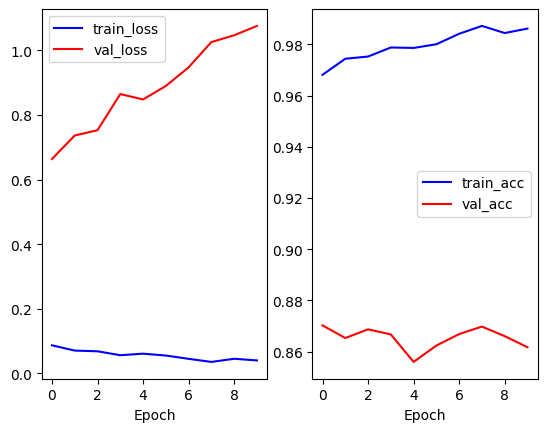

In [18]:
plt.subplot(1,2,1) # loss

plt.plot(history.history["loss"], "b-", label="train_loss" ) # train - loss
plt.plot(history.history["val_loss"], "r-", label="val_loss" ) # val - loss
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1,2,2) # acc

plt.plot(history.history["accuracy"], "b-", label="train_acc" ) # train - acc
plt.plot(history.history["val_accuracy"], "r-", label="val_acc" ) # val - acc
plt.xlabel("Epoch")
plt.legend()